In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

Exercise 1 

In [2]:
ds_sst = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
ds_sst = ds_sst.sel(time = slice('1960', '2019')) 
ds_sst.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 720, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2019-12-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

In [3]:
#make SST anomaly
sst_clim = ds_sst.sst.groupby('time.month').mean(dim = 'time')
sst_anom = ds_sst.sst.groupby('time.month') - sst_clim

In [4]:
sst_anom

<xarray.DataArray 'sst' (time: 720, lat: 89, lon: 180)>
array([[[ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
...
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[-4.8828125e-04, -3.9744377e-04, -1.5318394e-04, ...,
         -2.0480156e-04, -3.4177303e-04, -4.8625469e-04],
        [-4.2283535e-04, -2.3734570e-04,  9.5367432e-07, ...,
          9.5367432e-07, -1.7452240e-04, -3.8838387e-04],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [5]:
#detrend 移掉趨勢 
#區分出variability跟trend。
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, sst_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~sst_anom.isnull())

In [6]:
sst_anom_nino34 = sst_anom_detrended.sel(lat = slice(5, -5), lon = slice(190, 240)) 
sst_anom_nino34_mean = sst_anom_nino34.mean(dim = ('lon', 'lat'))
oni34 = sst_anom_nino34_mean.rolling(time = 3, center=True).mean()
ds_oni = oni34.sel(time=slice('1979', '2019'))  

In [7]:
ds_oni

<xarray.DataArray 'sst' (time: 492)>
array([ 4.02766578e-02,  7.54021108e-02,  1.64053202e-01,  1.93302572e-01,
        1.17662780e-01, -5.84308803e-02, -4.29272205e-02,  1.12975441e-01,
        2.84495950e-01,  4.08186495e-01,  4.81300712e-01,  6.18237436e-01,
        5.92641294e-01,  4.50075805e-01,  2.87834078e-01,  2.78961062e-01,
        3.58264804e-01,  3.44616711e-01,  1.61417007e-01, -3.43453884e-02,
       -1.21325731e-01, -3.63521799e-02,  6.40136525e-02,  2.44227536e-02,
       -1.56559482e-01, -3.62088621e-01, -3.78644407e-01, -3.20136309e-01,
       -2.46283740e-01, -2.99126327e-01, -3.16579700e-01, -2.61162430e-01,
       -1.69616982e-01, -1.35410994e-01, -1.43079922e-01, -4.64142393e-03,
        7.59864450e-02,  2.06319183e-01,  2.72267610e-01,  5.13714790e-01,
        6.63142323e-01,  7.00238883e-01,  7.59722829e-01,  1.04608226e+00,
        1.56074333e+00,  1.95013690e+00,  2.17710638e+00,  2.29171109e+00,
        2.29493117e+00,  2.04346466e+00,  1.62103271e+00,  1.31735063e+00,
        1.05972290e+00,  6.94292068e-01,  2.76452869e-01, -1.11021876e-01,
       -4.81281877e-01, -8.30263078e-01, -1.00771129e+00, -8.53780508e-01,
       -4.92122978e-01, -3.01804930e-01, -2.65568256e-01, -4.09873813e-01,
       -5.21875024e-01, -4.80600834e-01, -3.49570453e-01, -1.95794076e-01,
       -2.73924172e-01, -5.91977477e-01, -9.31824684e-01, -1.09590745e+00,
       -9.44856882e-01, -7.40382373e-01, -7.06307292e-01, -7.69871652e-01,
       -7.95423269e-01, -6.67361915e-01, -5.42769969e-01, -5.04406333e-01,
...
       -3.36863369e-01, -2.63761073e-01, -2.64450938e-01, -3.70144099e-01,
       -5.33210456e-01, -5.52694798e-01, -3.19438159e-01,  2.81226840e-02,
        2.11206168e-01,  1.45560488e-01,  6.74237846e-04, -1.21734943e-02,
        1.33607775e-01,  3.85768861e-01,  5.21778941e-01,  5.45522094e-01,
        4.41178381e-01,  3.86832803e-01,  4.86888707e-01,  6.85159087e-01,
        9.33570385e-01,  1.16962123e+00,  1.47314441e+00,  1.78020263e+00,
        2.05921912e+00,  2.31548738e+00,  2.46215487e+00,  2.52572799e+00,
        2.36863613e+00,  2.04439020e+00,  1.53295743e+00,  9.25663173e-01,
        3.94785643e-01, -7.84432888e-02, -4.01408732e-01, -6.15058541e-01,
       -7.25060403e-01, -7.93619871e-01, -7.78726697e-01, -6.81232929e-01,
       -4.62200165e-01, -2.63986290e-01, -1.45543218e-02,  1.69563457e-01,
        2.84981132e-01,  2.87533641e-01,  8.82741436e-02, -1.98684067e-01,
       -4.95638549e-01, -7.72221267e-01, -9.67435837e-01, -1.10810757e+00,
       -1.04989386e+00, -9.62188601e-01, -7.66545177e-01, -5.34624636e-01,
       -2.33634561e-01, -3.38854603e-02,  3.71426195e-02,  1.45778924e-01,
        3.81697178e-01,  6.43861353e-01,  7.73168981e-01,  6.88192070e-01,
        6.25632048e-01,  6.24952614e-01,  6.53942704e-01,  6.37433171e-01,
        5.34733117e-01,  4.28905457e-01,  2.27929235e-01,  5.69002256e-02,
        8.07158202e-02,  2.34269410e-01,  3.87749165e-01,             nan],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1979-01-01 1979-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

PartII: Correlation of map

#Method I: xarray

In [8]:
sst_anom

<xarray.DataArray 'sst' (time: 720, lat: 89, lon: 180)>
array([[[ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
...
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[-4.8828125e-04, -3.9744377e-04, -1.5318394e-04, ...,
         -2.0480156e-04, -3.4177303e-04, -4.8625469e-04],
        [-4.2283535e-04, -2.3734570e-04,  9.5367432e-07, ...,
          9.5367432e-07, -1.7452240e-04, -3.8838387e-04],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [15]:
#oni34
positive_oni_34 = ((ds_oni>0.5).astype('b').rolling(time=5, center=True).sum()==5) #選出高於0.5
negative_oni_34 = ((ds_oni<0.5).astype('b').rolling(time=5, center=True).sum()==5) #選出低於0.5
#positive_oni_34.astype('i').plot(marker='.', label='positive')
#(-negative_oni_34.astype('i')).plot(marker='.', label='negative')
#plt.legend()

In [16]:
sst_anom.where(positive_oni_34).mean(dim='time')

<xarray.DataArray 'sst' (lat: 89, lon: 180)>
array([[-1.0052770e-03, -9.8360411e-04, -9.4962615e-04, ...,
        -7.4233609e-04, -9.0396404e-04, -1.0168039e-03],
       [-9.6421607e-04, -1.0823326e-03, -1.1558698e-03, ...,
        -2.8527447e-04, -6.3219003e-04, -8.0464286e-04],
       [-2.1442771e-05, -3.2718148e-04, -5.1936012e-04, ...,
        -1.8480916e-04, -1.1804700e-04, -5.2645802e-05],
       ...,
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0

In [20]:
sst_anom

<xarray.DataArray 'sst' (time: 720, lat: 89, lon: 180)>
array([[[ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
...
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[-4.8828125e-04, -3.9744377e-04, -1.5318394e-04, ...,
         -2.0480156e-04, -3.4177303e-04, -4.8625469e-04],
        [-4.2283535e-04, -2.3734570e-04,  9.5367432e-07, ...,
          9.5367432e-07, -1.7452240e-04, -3.8838387e-04],
        [ 9.5367432e-07,  9.5367432e-07,  9.5367432e-07, ...,
          9.5367432e-07,  9.5367432e-07,  9.5367432e-07],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]]], dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
  * time     (time) datetime64[ns] 1960-01-01 1960-02-01 ... 2019-12-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 2 3 4 5 6 7 8 9 10 11 12

In [21]:
sst_anom.where(positive_oni_34).mean(dim='time')

<xarray.DataArray 'sst' (lat: 89, lon: 180)>
array([[-1.0052770e-03, -9.8360411e-04, -9.4962615e-04, ...,
        -7.4233609e-04, -9.0396404e-04, -1.0168039e-03],
       [-9.6421607e-04, -1.0823326e-03, -1.1558698e-03, ...,
        -2.8527447e-04, -6.3219003e-04, -8.0464286e-04],
       [-2.1442771e-05, -3.2718148e-04, -5.1936012e-04, ...,
        -1.8480916e-04, -1.1804700e-04, -5.2645802e-05],
       ...,
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan]], dtype=float32)
Coordinates:
  * lat      (lat) float32 88.0 86.0 84.0 82.0 80.0 ... -82.0 -84.0 -86.0 -88.0
  * lon      (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0

In [22]:
test1 = sst_anom.mean(dim='time')
test2 = sst_anom.where(negative_oni_34).mean(dim='time')

In [23]:
r_map = xr.corr(test1,test2)
r_map

NameError: name 'dask' is not defined

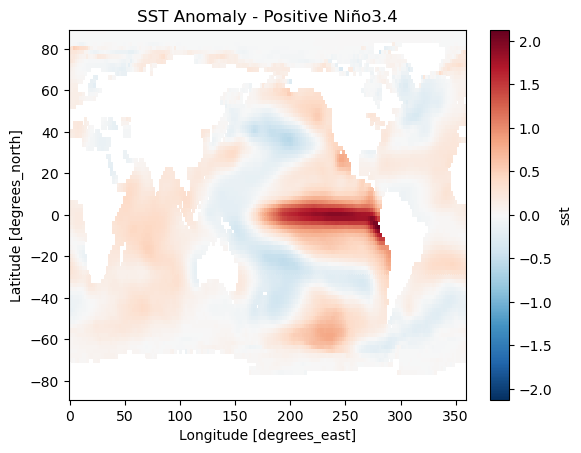

In [24]:
sst_anom.where(positive_oni_34).mean(dim='time').plot()
plt.title('SST Anomaly - Positive Niño3.4');

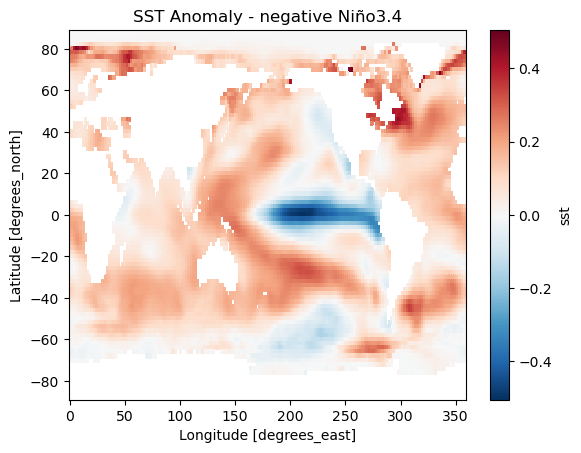

In [25]:
sst_anom.where(negative_oni_34).mean(dim='time').plot()
plt.title('SST Anomaly - negative Niño3.4');
